In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [15]:
dataset_path = "/kaggle/input/datasets/niclinn/c5data2"

print("Dataset Path:", dataset_path)
print("Path Exists:", os.path.exists(dataset_path))

Dataset Path: /kaggle/input/datasets/niclinn/c5data2
Path Exists: True


In [16]:
import os

folders = os.listdir(dataset_path)

print("Contents of the dataset:")
for item in folders:
    print(item)

Contents of the dataset:
label
images


In [17]:
images_path = os.path.join(dataset_path, "images")
labels_path = os.path.join(dataset_path, "label")

print("Number of images:", len(os.listdir(images_path)))
print("Number of label files:", len(os.listdir(labels_path)))

print("\nFirst 5 image files:")
print(os.listdir(images_path)[:5])

print("\nFirst 5 label files:")
print(os.listdir(labels_path)[:5])

Number of images: 1
Number of label files: 1

First 5 image files:
['images']

First 5 label files:
['label']


In [18]:
images_path = os.path.join(dataset_path, "images", "images")
labels_path = os.path.join(dataset_path, "label", "label")

print("Images folder exists:", os.path.exists(images_path))
print("Labels folder exists:", os.path.exists(labels_path))

print("\nNumber of images:", len(os.listdir(images_path)))
print("Number of labels:", len(os.listdir(labels_path)))

print("\nFirst 10 images:")
print(os.listdir(images_path)[:10])

print("\nFirst 10 label files:")
print(os.listdir(labels_path)[:10])

Images folder exists: True
Labels folder exists: True

Number of images: 5
Number of labels: 1075

First 10 images:
['inclusion', 'waist folding', 'rolled_pit', 'deburring', 'silk_spot']

First 10 label files:
['img_06_3436814300_00056.xml', 'img_01_425005700_00501.xml', 'img_07_4406743300_00036.xml', 'img_05_436164700_01553.xml', 'img_07_3436814000_00691.xml', 'img_07_425507200_00974.xml', 'img_03_425501800_01214.xml', 'img_02_436153600_00700.xml', 'img_03_436184600_00786.xml', 'img_01_425005700_00181.xml']


In [19]:
import os

images_root = "/kaggle/input/datasets/niclinn/c5data2/images/images"

classes = sorted(os.listdir(images_root))

print("Classes found:\n")

total_images = 0

for cls in classes:
    class_path = os.path.join(images_root, cls)

    if os.path.isdir(class_path):
        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
        ])

        print(f"{cls} : {count} images")
        total_images += count

print("\nTotal Images:", total_images)

Classes found:

deburring : 43 images
inclusion : 211 images
rolled_pit : 28 images
silk_spot : 649 images
waist folding : 144 images

Total Images: 1075


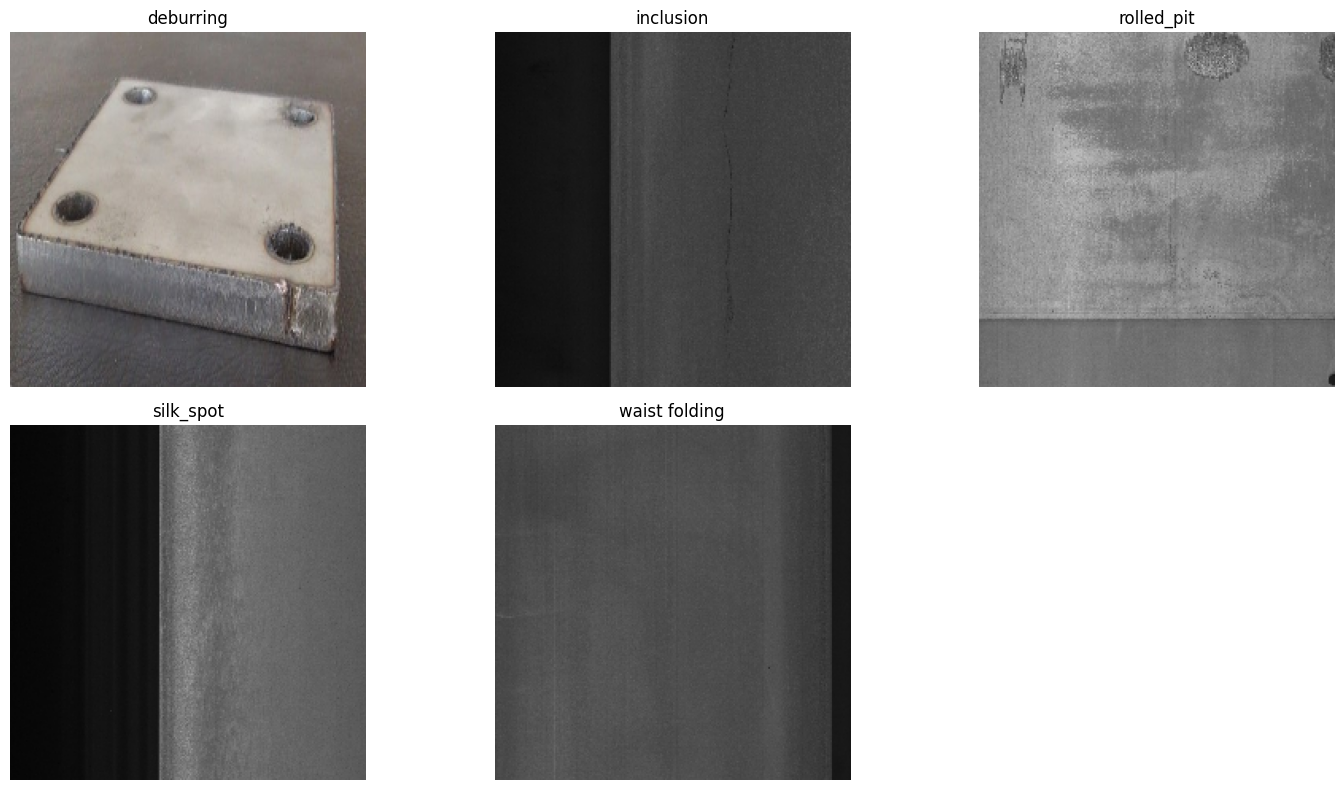

In [20]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

images_root = "/kaggle/input/datasets/niclinn/c5data2/images/images"

classes = sorted(os.listdir(images_root))

plt.figure(figsize=(15,8))

for i, cls in enumerate(classes):
    class_path = os.path.join(images_root, cls)

    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    img = load_img(image_path, target_size=(224,224))

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dataset path
images_root = "/kaggle/input/datasets/niclinn/c5data2/images/images"

# Data preprocessing and augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20,
    rotation_range=20,
    zoom_range=0.20,
    horizontal_flip=True
)

# Training dataset
train_generator = train_datagen.flow_from_directory(
    images_root,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Validation dataset
validation_generator = train_datagen.flow_from_directory(
    images_root,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 863 images belonging to 5 classes.
Found 212 images belonging to 5 classes.


In [22]:
# Display class names and their assigned labels

print("Class Labels:\n")

for class_name, index in train_generator.class_indices.items():
    print(f"{index} --> {class_name}")

Class Labels:

0 --> deburring
1 --> inclusion
2 --> rolled_pit
3 --> silk_spot
4 --> waist folding


In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([

    # First Convolution Layer
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(pool_size=(2,2)),

    # Second Convolution Layer
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    # Third Convolution Layer
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    # Flatten
    Flatten(),

    # Fully Connected Layer
    Dense(256, activation='relu'),
    Dropout(0.5),

    # Output Layer
    Dense(5, activation='softmax')
])

print("CNN Model Created Successfully!")

CNN Model Created Successfully!


In [24]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [26]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Stop training if validation loss doesn't improve
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Save the best model
checkpoint = ModelCheckpoint(
    "best_metal_defect_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# Train the model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 670ms/step - accuracy: 0.7017 - loss: 0.7747
Epoch 1: val_accuracy improved from None to 0.65566, saving model to best_metal_defect_model.keras

Epoch 1: finished saving model to best_metal_defect_model.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 25s 947ms/step - accuracy: 0.6929 - loss: 0.7819 - val_accuracy: 0.6557 - val_loss: 0.6499
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 661ms/step - accuracy: 0.7058 - loss: 0.7666
Epoch 2: val_accuracy did not improve from 0.65566
27/27 ━━━━━━━━━━━━━━━━━━━━ 23s 838ms/step - accuracy: 0.6848 - loss: 0.7889 - val_accuracy: 0.6509 - val_loss: 0.6493
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - accuracy: 0.7058 - loss: 0.7559
Epoch 3: val_accuracy improved from 0.65566 to 0.66509, saving model to best_metal_defect_model.keras

Epoch 3: finished saving model to best_metal_defect_model.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 24s 894ms/step - accuracy: 0.6964 - loss: 0.7742 - val_accuracy: 0.6651 - val_loss: 0.6961
Epoch 

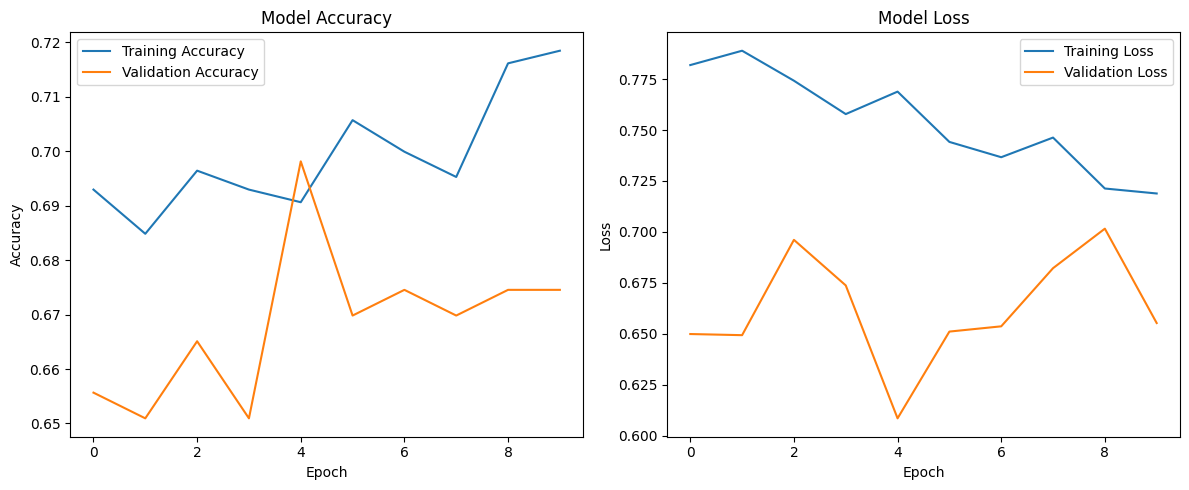

In [27]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [30]:
import os

dataset_path = "/kaggle/input"

for root, dirs, files in os.walk(dataset_path):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/niclinn
/kaggle/input/datasets/niclinn/c5data2
/kaggle/input/datasets/niclinn/c5data2/label
/kaggle/input/datasets/niclinn/c5data2/label/label
/kaggle/input/datasets/niclinn/c5data2/images
/kaggle/input/datasets/niclinn/c5data2/images/images
/kaggle/input/datasets/niclinn/c5data2/images/images/inclusion
/kaggle/input/datasets/niclinn/c5data2/images/images/waist folding
/kaggle/input/datasets/niclinn/c5data2/images/images/rolled_pit
/kaggle/input/datasets/niclinn/c5data2/images/images/deburring
/kaggle/input/datasets/niclinn/c5data2/images/images/silk_spot


In [31]:
print(validation_generator)

In [32]:
# Evaluate on validation data
loss, accuracy = model.evaluate(validation_generator)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy*100:.2f}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 670ms/step - accuracy: 0.6934 - loss: 0.6156
Validation Loss: 0.6156
Validation Accuracy: 69.34%


In [33]:
import numpy as np

# Reset generator
validation_generator.reset()

# Predict classes
predictions = model.predict(validation_generator)

# Predicted class index
y_pred = np.argmax(predictions, axis=1)

# True class index
y_true = validation_generator.classes

# Class names
class_names = list(validation_generator.class_indices.keys())

print("Prediction completed!")

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 676ms/step
Prediction completed!


In [34]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

               precision    recall  f1-score   support

    deburring       0.67      0.75      0.71         8
    inclusion       0.90      0.21      0.35        42
   rolled_pit       0.00      0.00      0.00         5
    silk_spot       0.67      0.99      0.80       129
waist folding       1.00      0.04      0.07        28

     accuracy                           0.68       212
    macro avg       0.65      0.40      0.38       212
 weighted avg       0.74      0.68      0.59       212



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


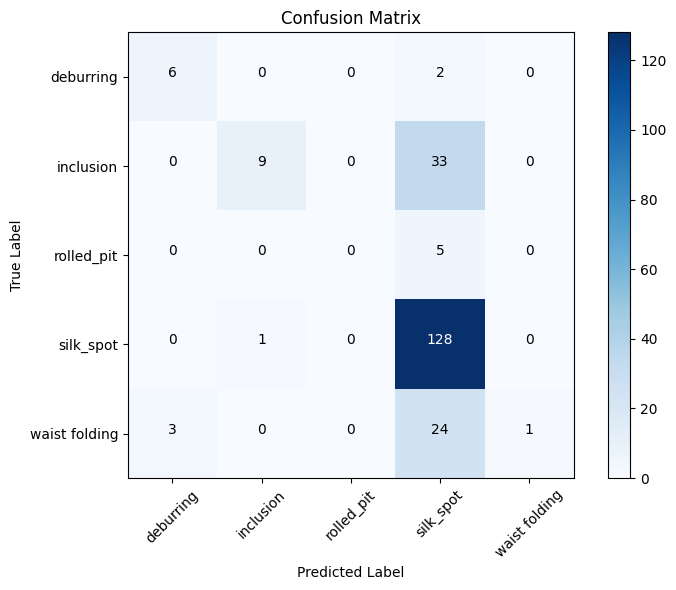

In [35]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Display values inside cells
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, str(cm[i, j]),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.tight_layout()
plt.show()

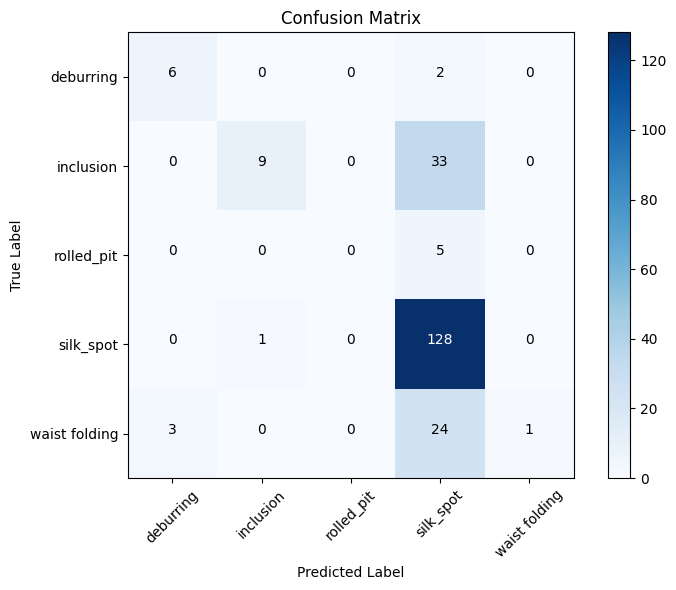

In [36]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add numbers inside boxes
thresh = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

In [37]:
model.save("metal_defect_cnn.h5")
print("Model saved successfully!")

Model saved successfully!


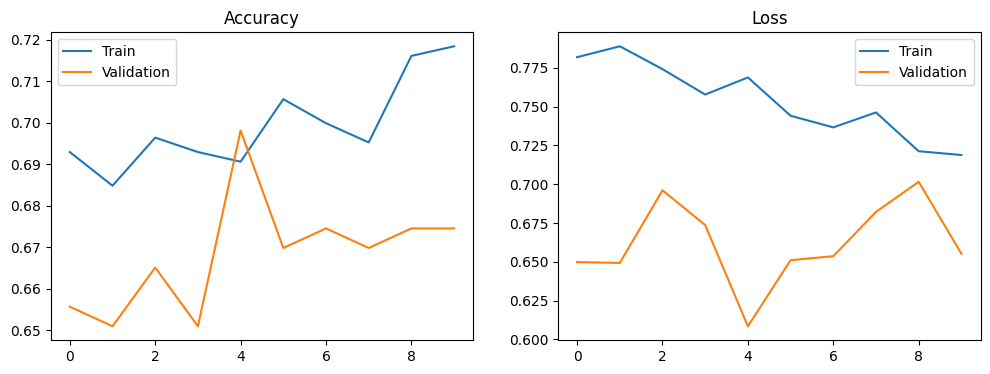

In [39]:
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.legend()

plt.show()